# 1. 必要なライブラリのインポート，デバイスの設定

In [22]:
import os
import pandas as pd
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import glob
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda:0


# 2. データセットクラスの定義

In [2]:
class BugDetectionDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.data_frame.iloc[idx, 0])  # 'frame'列から画像ファイル名を取得
        image = Image.open(img_name)
        label = self.data_frame.iloc[idx, 1]  # 'label'列からラベルを取得 (0 または 1)
        label = torch.tensor(int(label))  # ラベルをテンソルに変換

        if self.transform:
            image = self.transform(image)

        return image, label

# 3. データ前処理の設定

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 入力画像サイズの調整
    transforms.ToTensor(),  # 画像をテンソルに変換
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # 正規化
])

# 4. ディレクトリからデータの振り分けを行う関数

In [4]:
def load_data(data_dir, transform):
    train_data = []
    test_data = []
    val_data = []

    # 'data_for_server' 直下の全てのサブディレクトリを探索
    sub_dirs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    
    for sub_dir in sub_dirs:
        video_dir = os.path.join(data_dir, sub_dir)
        label_file = os.path.join(video_dir, 'frame_label.csv')  # CSVファイルは'frame_label.csv'
        frames_dir = os.path.join(video_dir, 'trimmed_frames')
        
        if os.path.isfile(os.path.join(video_dir, 'train')):
            train_data.append(BugDetectionDataset(csv_file=label_file, root_dir=frames_dir, transform=transform))
        elif os.path.isfile(os.path.join(video_dir, 'test')):
            test_data.append(BugDetectionDataset(csv_file=label_file, root_dir=frames_dir, transform=transform))
        elif os.path.isfile(os.path.join(video_dir, 'validation')):
            val_data.append(BugDetectionDataset(csv_file=label_file, root_dir=frames_dir, transform=transform))

    return train_data, test_data, val_data

# 5. データセットのロード

In [6]:
train_data, test_data, val_data = load_data('/data/uenaka/data_for_server', transform)

# データを DataLoader に変換
def combine_datasets(datasets, batch_size=32, shuffle=True):
    combined_data = torch.utils.data.ConcatDataset(datasets)
    return DataLoader(combined_data, batch_size=batch_size, shuffle=shuffle)

train_loader = combine_datasets(train_data)
test_loader = combine_datasets(test_data, shuffle=False)
val_loader = combine_datasets(val_data, shuffle=False)

# 6. CNNモデルの定義（Pre-trained ResNetを使用）

In [7]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # 出力はバグ/非バグの2クラス
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/uenaka/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100.0%


# 7. 損失関数と最適化関数の定義

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# 8. トレーニング関数の定義

In [9]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()  # トレーニングモード
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # 勾配をリセット
            optimizer.zero_grad()

            # 順伝播
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 逆伝播と最適化
            loss.backward()
            optimizer.step()

            # 統計の更新
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')

        # バリデーション
        model.eval()  # 評価モード
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model(val_inputs)
                _, val_predicted = torch.max(val_outputs.data, 1)
                val_total += val_labels.size(0)
                val_correct += (val_predicted == val_labels).sum().item()

        print(f'Validation Accuracy: {100 * val_correct / val_total:.2f}%')

# 9. 学習の実行

In [10]:
train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=10)

Epoch [1/10], Loss: 0.0083, Accuracy: 99.75%
Validation Accuracy: 99.73%
Epoch [2/10], Loss: 0.0012, Accuracy: 99.96%
Validation Accuracy: 99.73%
Epoch [3/10], Loss: 0.0005, Accuracy: 99.98%
Validation Accuracy: 99.73%
Epoch [4/10], Loss: 0.0003, Accuracy: 99.99%
Validation Accuracy: 99.72%
Epoch [5/10], Loss: 0.0002, Accuracy: 100.00%
Validation Accuracy: 99.72%
Epoch [6/10], Loss: 0.0001, Accuracy: 100.00%
Validation Accuracy: 99.74%
Epoch [7/10], Loss: 0.0001, Accuracy: 100.00%
Validation Accuracy: 99.76%
Epoch [8/10], Loss: 0.0001, Accuracy: 100.00%
Validation Accuracy: 99.76%
Epoch [9/10], Loss: 0.0000, Accuracy: 100.00%
Validation Accuracy: 99.75%
Epoch [10/10], Loss: 0.0000, Accuracy: 100.00%
Validation Accuracy: 99.76%


# 10. テストデータでモデルを評価して，各画像のバグである確率をCSVに記録

In [14]:
def predict_and_save_to_csv(model, data_dir):
    model.eval()  # モデルを評価モードに設定
    with torch.no_grad():  # 勾配を計算しない設定
        # 各ディレクトリのテストデータを処理
        for sub_dir in os.listdir(data_dir):
            video_dir = os.path.join(data_dir, sub_dir)
            label_file = os.path.join(video_dir, 'frame_label.csv')  # ラベルCSVファイル
            frames_dir = os.path.join(video_dir, 'trimmed_frames')

            if os.path.isfile(os.path.join(video_dir, 'test')) and os.path.exists(label_file):
                print(f"Processing directory: {video_dir}")

                # CSVファイルのデータフレームを読み込む
                df = pd.read_csv(label_file)

                # 確率を保存するリストを初期化
                probabilities = []

                # 各画像に対して予測を行い、バグである確率を取得
                for i, row in df.iterrows():
                    img_name = os.path.join(frames_dir, row['frame'])
                    image = Image.open(img_name)
                    image = transform(image).unsqueeze(0).to(device)  # 変換と次元調整

                    # モデルの出力を取得
                    output = model(image)
                    prob = torch.softmax(output, dim=1)[0, 1].item()  # バグである確率を取得
                    probabilities.append(prob)

                # データフレームに新しい 'output' 列を追加
                df['output'] = probabilities

                # CSVファイルを上書き保存
                df.to_csv(label_file, index=False)
                print(f"Saved predictions to {label_file}")

predict_and_save_to_csv(model, '/data/uenaka/data_for_server')


Processing directory: /data/uenaka/data_for_server/1-8-2021-12-08
Saved predictions to /data/uenaka/data_for_server/1-8-2021-12-08/frame_label.csv
Processing directory: /data/uenaka/data_for_server/120-8-2021-01-31
Saved predictions to /data/uenaka/data_for_server/120-8-2021-01-31/frame_label.csv
Processing directory: /data/uenaka/data_for_server/0-7-2022-02-13
Saved predictions to /data/uenaka/data_for_server/0-7-2022-02-13/frame_label.csv
Processing directory: /data/uenaka/data_for_server/16-16-2022-07-06
Saved predictions to /data/uenaka/data_for_server/16-16-2022-07-06/frame_label.csv


# 11. 動画ごとにバグ確率を時系列的にグラフで表示

Processing CSV: /data/uenaka/data_for_server/1-8-2021-12-08/frame_label.csv


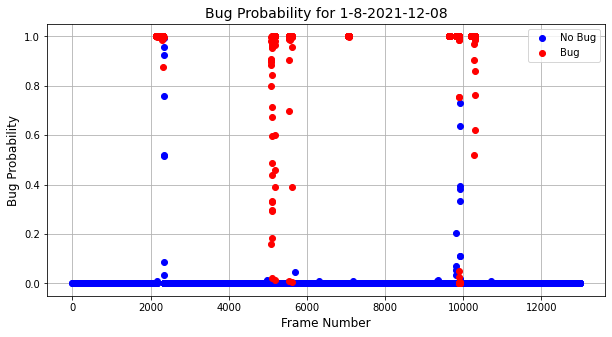

Plot saved for 1-8-2021-12-08
Processing CSV: /data/uenaka/data_for_server/120-8-2021-01-31/frame_label.csv


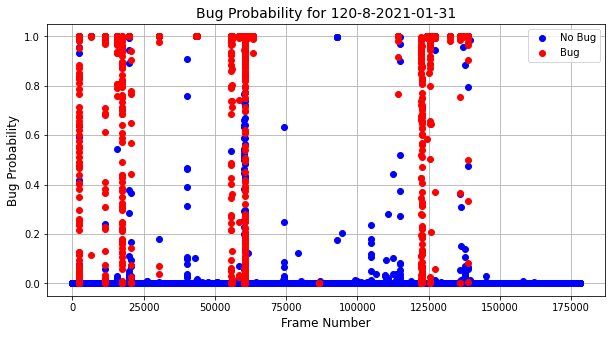

Plot saved for 120-8-2021-01-31
Processing CSV: /data/uenaka/data_for_server/0-7-2022-02-13/frame_label.csv


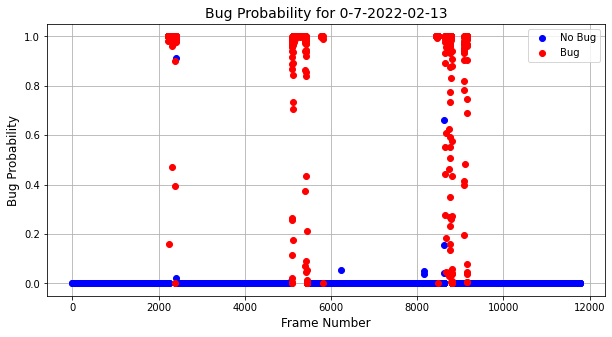

Plot saved for 0-7-2022-02-13
Processing CSV: /data/uenaka/data_for_server/16-16-2022-07-06/frame_label.csv


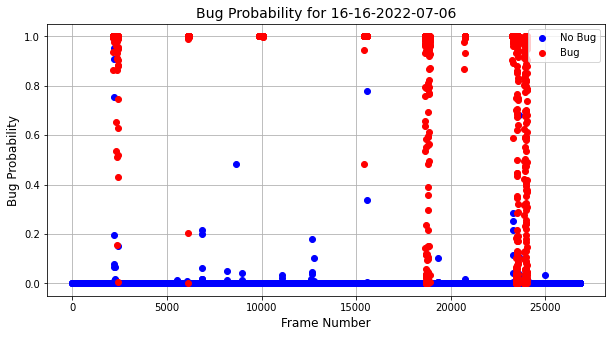

Plot saved for 16-16-2022-07-06


In [21]:
def plot_output_probabilities(data_dir):
    # 各ディレクトリのCSVファイルを処理
    for sub_dir in os.listdir(data_dir):
        video_dir = os.path.join(data_dir, sub_dir)
        label_file = os.path.join(video_dir, 'frame_label.csv')  # CSVファイルのパス

        if os.path.isfile(os.path.join(video_dir, 'test')):
            print(f"Processing CSV: {label_file}")
            
            # CSVを読み込み
            df = pd.read_csv(label_file)

            # 'frame'列からフレーム番号を抽出（例：'0.jpg' → 0）
            df['frame_num'] = df['frame'].str.extract(r'(\d+)').astype(int)

            # グラフの作成
            plt.figure(figsize=(10, 5))

            # ラベルが0のデータを青色でプロット
            df_label_0 = df[df['label'] == 0]
            plt.plot(df_label_0['frame_num'], df_label_0['output'], 'bo', label='No Bug')

            # ラベルが1のデータを赤色でプロット
            df_label_1 = df[df['label'] == 1]
            plt.plot(df_label_1['frame_num'], df_label_1['output'], 'ro', label='Bug')

            # グラフのタイトルとラベル
            plt.title(f"Bug Probability for {sub_dir}", fontsize=14)
            plt.xlabel("Frame Number", fontsize=12)
            plt.ylabel("Bug Probability", fontsize=12)

            # 軸の数字を表示
            plt.xticks(fontsize=10)
            plt.yticks(fontsize=10)

            # 凡例とグリッドを追加し、プロットを表示して保存
            plt.legend()
            plt.grid()
            plt.show()  # 追加: 表示内容を確認
            plt.savefig(os.path.join(video_dir, 'output_plot.png'))
            plt.close()
            print(f"Plot saved for {sub_dir}")

# 実行
plot_output_probabilities('/data/uenaka/data_for_server')

# 12. 混同行列， Accuracy，Precision，Recallの計算

In [23]:
def evaluate_model_metrics(data_dir):
    # 各CSVファイルから全てのデータを読み込むためのリスト
    all_true_labels = []
    all_pred_probs = []
    
    # 各ディレクトリのCSVファイルを処理
    for sub_dir in os.listdir(data_dir):
        video_dir = os.path.join(data_dir, sub_dir)
        label_file = os.path.join(video_dir, 'frame_label.csv')  # CSVファイルのパス

        if os.path.isfile(os.path.join(video_dir, 'test')):
            print(f"Processing CSV: {label_file}")
            
            # CSVを読み込み
            df = pd.read_csv(label_file)
            
            # 必要なデータ（ラベルと予測確率）をリストに追加
            all_true_labels.extend(df['label'].tolist())
            all_pred_probs.extend(df['output'].tolist())

    # 二値分類のため、確率出力を0.5以上で1、未満で0として二値に変換
    all_pred_labels = [1 if prob >= 0.5 else 0 for prob in all_pred_probs]
    
    # 混同行列、Accuracy、Precision、Recallの計算
    conf_matrix = confusion_matrix(all_true_labels, all_pred_labels)
    accuracy = accuracy_score(all_true_labels, all_pred_labels)
    precision = precision_score(all_true_labels, all_pred_labels)
    recall = recall_score(all_true_labels, all_pred_labels)
    
    # 結果の表示
    print("Confusion Matrix:\n", conf_matrix)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

# 実行
evaluate_model_metrics('/data/uenaka/data_for_server')

Processing CSV: /data/uenaka/data_for_server/1-8-2021-12-08/frame_label.csv
Processing CSV: /data/uenaka/data_for_server/120-8-2021-01-31/frame_label.csv
Processing CSV: /data/uenaka/data_for_server/0-7-2022-02-13/frame_label.csv
Processing CSV: /data/uenaka/data_for_server/16-16-2022-07-06/frame_label.csv
Confusion Matrix:
 [[224314    106]
 [   815   4366]]
Accuracy: 0.9960
Precision: 0.9763
Recall: 0.8427


# 13. モデルの保存

In [19]:
model_save_path = '/data/uenaka/trained_model.pth'

# モデルのパラメータのみを保存（推奨）
torch.save(model.state_dict(), model_save_path)

print(f'Model saved to {model_save_path}')

Model saved to /data/uenaka/trained_model.pth


# モデルの読み込み

In [ ]:
# model = models.resnet18(pretrained=False)  # 学習済みパラメータをロードするため、pretrained=False
# num_ftrs = model.fc.in_features
# model.fc = nn.Linear(num_ftrs, 2)  # 出力クラス数に合わせる
# model.load_state_dict(torch.load('trained_model.pth'))
# model = model.to(device)

# print('Model loaded successfully')